### Loggin configs

In [1]:
import logging
import sys

# Remove existing handlers
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

class ColorFormatter(logging.Formatter):
    COLORS = {
        logging.DEBUG: "\033[96m",    # Cyan
        logging.INFO: "\033[37m",     # Green
        logging.WARNING: "\033[93m",  # Yellow
        logging.ERROR: "\033[91m",    # Red
        logging.CRITICAL: "\033[95m", # Magenta
    }
    RESET = "\033[0m"

    def format(self, record):
        color = self.COLORS.get(record.levelno, self.RESET)
        message = super().format(record)
        return f"{color}{message}{self.RESET}"

handler = logging.StreamHandler(sys.stdout)
handler.setFormatter(ColorFormatter("%(levelname)s: %(message)s"))

logger = logging.getLogger()
logger.addHandler(handler)
logger.setLevel(logging.INFO)

# Phase 1: Exploratory Data Analysis (EDA)

### Imports and Loading the Data
#### First, we load the data and set up our visualization libraries.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Configure logging
# logging.basicConfig(
#     level=logging.INFO,
#     format="%(asctime)s - %(levelname)s - %(message)s"
# )

# Set visual style for Seaborn
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the dataset
file_path = '/kaggle/input/datasets/himanshupoddar/zomato-bangalore-restaurants/zomato.csv'

df = pd.read_csv(file_path)

logging.info("Dataset loaded successfully!")
logging.info(f"Total rows: {df.shape[0]}, Total columns: {df.shape[1]}")

INFO: NumExpr defaulting to 4 threads.
INFO: Dataset loaded successfully!
INFO: Total rows: 51717, Total columns: 17


### Basic Data Profiling
#### Before we draw graphs, we need to see the raw numbers, column types, and where the missing data is hiding.

In [3]:
# 1. Preview the data
display(df.head(3))

# 2. Check data types and non-null counts
logging.info("\n--- Data Types & Non-Null Counts ---")
df.info()

# 3. Calculate percentage of missing values per column
logging.info("\n--- Percentage of Missing Values ---")
missing_percentages = (df.isnull().sum() / len(df)) * 100
logging.info(missing_percentages[missing_percentages > 0].sort_values(ascending=False))

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari


INFO: 
--- Data Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null 

##### Notice dish_liked has a massive amount of missing data (around 50%). You'll also see that rate and approx_cost(for two people) are currently stored as object (strings), which means we can't do math on them yet.

### Univariate Analysis (Locations & Types)
#### Let's visualize where restaurants are concentrated and what types of restaurants are most common.

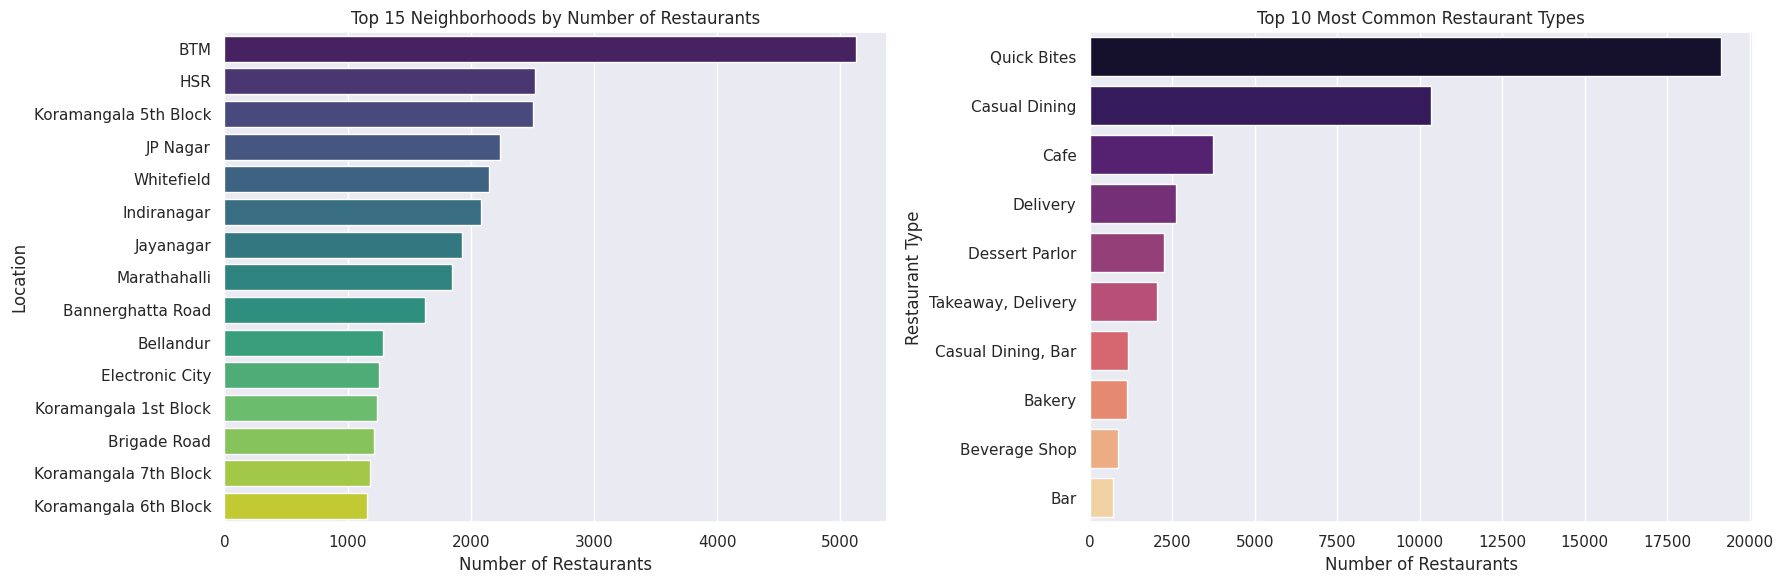

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Top 15 Locations
top_locations = df['location'].value_counts().head(15)
sns.barplot(
    x=top_locations.values,
    y=top_locations.index,
    hue=top_locations.index,
    ax=axes[0],
    palette="viridis",
    legend=False
)
axes[0].set_title('Top 15 Neighborhoods by Number of Restaurants')
axes[0].set_xlabel('Number of Restaurants')
axes[0].set_ylabel('Location')

# Plot 2: Top 10 Restaurant Types
top_rest_types = df['rest_type'].value_counts().head(10)
sns.barplot(
    x=top_rest_types.values,
    y=top_rest_types.index,
    hue=top_rest_types.index,
    ax=axes[1],
    palette="magma",
    legend=False
)
axes[1].set_title('Top 10 Most Common Restaurant Types')
axes[1].set_xlabel('Number of Restaurants')
axes[1].set_ylabel('Restaurant Type')

plt.tight_layout()
plt.show()

##### Summary: BTM, HSR, and Koramangala usually dominate the location chart. "Quick Bites" and "Casual Dining" heavily dominate the restaurant types.

#### Services Offered (Online Order & Book Table)
#### Let's look at the proportion of restaurants offering online delivery vs. table booking.

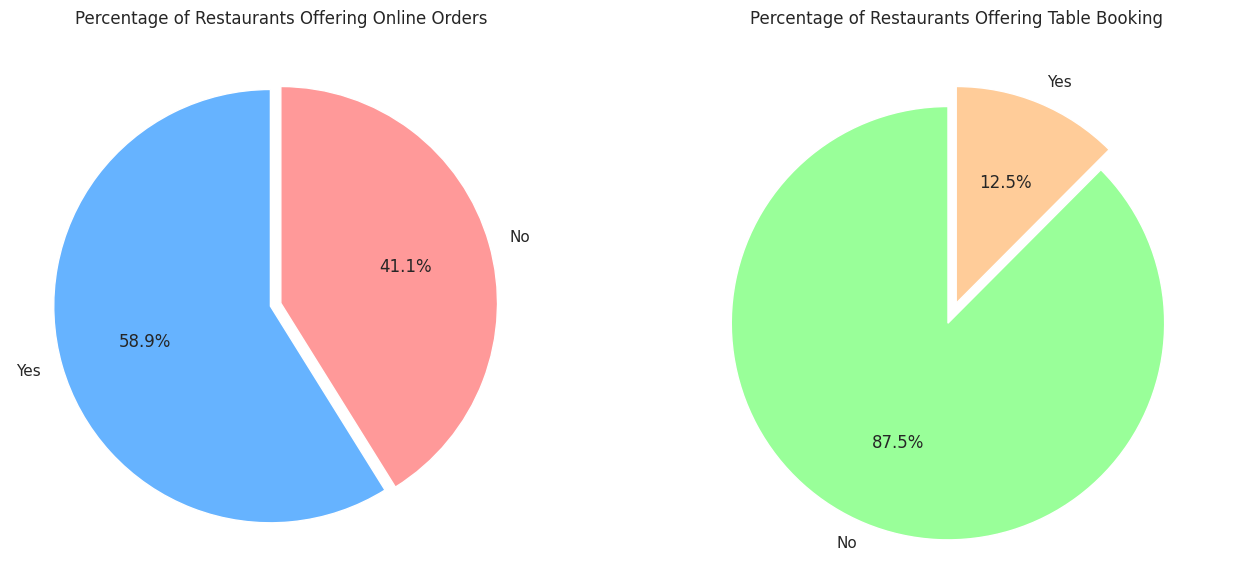

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Online Order
df['online_order'].value_counts().plot.pie(
    ax=axes[0], autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'], explode=[0.05, 0]
)
axes[0].set_title('Percentage of Restaurants Offering Online Orders')
axes[0].set_ylabel('') # Hide y-label for cleaner pie chart

# Plot 2: Book Table
df['book_table'].value_counts().plot.pie(
    ax=axes[1], autopct='%1.1f%%', startangle=90, colors=['#99ff99','#ffcc99'], explode=[0.1, 0]
)
axes[1].set_title('Percentage of Restaurants Offering Table Booking')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

##### Summary: See that a majority of restaurants offer online ordering, but only a very small fraction (usually around 12-15%) offer table booking, which aligns with the fact that "Quick Bites" are the most common restaurant type.


- Useless Columns Identified: Columns like url, address, and phone provide no statistical value for our clustering or sentiment analysis. We need to drop them.
- Data Type Issues: rate (e.g., "4.1/5") and approx_cost(for two people) (e.g., "1,200") need to be cleaned of strings/ commas and converted to numeric floats/integers.
- Missing Data: We need a strategy for columns with missing values (drop rows, or fill them).
- Target Variable Prep: We can see the text for sentiment analysis lives in reviews_list, but we will need to extract the clean text from the messy formatting it currently has.

Columns like "rate" (ratings) and "approx_cost" are currently stored as text strings instead of numbers, we literally cannot plot a histogram of costs or calculate the average rating yet.
Here is the exact flow of what we are doing:
- Pre-cleaning EDA (Done): Find the mess (missing values, wrong data types, useless columns).
- Phase 2 - Data Cleaning (Next): Fix the mess. Convert strings to numbers, handle missing values, and drop useless columns.
- Deep EDA: Once the data is clean, we will do the real EDA. We will plot the actual distribution of prices, see how price correlates with ratings, and look at which cuisines are the most expensive.

# Phase 2: Data Cleaning and Preparation

Our goals are:
- Drop columns that offer no analytical value.
- Fix the string issues in rate and approx_cost so they become usable numbers.
- Handle missing values (NaNs) and duplicates so our future machine learning models don't crash.

### Dropping & Renaming
#### First, let's remove the noise and rename long column names to make our coding life easier.

In [6]:
# Log initial columns
logging.info(f"Initial columns: {df.columns.tolist()}")

# Columns to drop
cols_to_drop = ['url', 'address', 'phone']

# Check which columns actually exist (safe practice)
existing_cols = [col for col in cols_to_drop if col in df.columns]

logging.info(f"\nColumns to be dropped: {existing_cols}")

# Drop columns
df = df.drop(existing_cols, axis=1)

# Log after dropping
logging.info(f"\nColumns after dropping: {df.columns.tolist()}")


# Rename columns
rename_map = {
    'approx_cost(for two people)': 'approx_cost',
    'listed_in(type)': 'type',
    'listed_in(city)': 'city'
}

# Log columns before renaming
logging.info(f"\nColumns before renaming: {df.columns.tolist()}: count: {len(df.columns.tolist())}")

df.rename(columns=rename_map, inplace=True)

# Log after renaming
logging.info(f"\nColumns after renaming: {df.columns.tolist()}")

INFO: Initial columns: ['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']
INFO: 
Columns to be dropped: ['url', 'address', 'phone']
INFO: 
Columns after dropping: ['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']
INFO: 
Columns before renaming: ['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']: count: 14
INFO: 
Columns after renaming: ['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost', 'reviews_list', 'menu_item', 'type', 'city']


### Cleaning the 'rate' (Rating) Column
The ratings currently look like "4.1/5", "NEW", or "-". We need to strip out the text and convert the valid ratings into float numbers (decimals).

In [7]:
import numpy as np

# Create a function to clean the rating text
def clean_rate(value):
    # If the value is missing, "NEW", or "-", turn it into a standard NaN (Not a Number)
    if pd.isnull(value) or value == 'NEW' or value == '-':
        return np.nan
    
    # Split the string by '/' and take the first part (e.g., "4.1" from "4.1/5")
    value = str(value).split('/')[0].strip()
    return float(value)

# Apply the function to the rate column
df['rate'] = df['rate'].apply(clean_rate)

logging.info("Rating column cleaned!")

INFO: Rating column cleaned!


##### If we change "NEW", "-", or NaN with 0 would be a problem ?

Yes, we we replacing "NEW", "-", or NaN with 0 would be a massive problem.
Here is exactly why that would ruin our models:

- For K-Means (Clustering): K-Means calculates physical "distance" between numbers. If a restaurant simply hasn't been rated yet ("NEW"), changing its rating to 0 tells the model mathematically that it is the worst restaurant in the city. The algorithm would group all brand-new restaurants alongside the lowest-rated, terrible restaurants.
- For the Cost Column: If we replaced missing costs with 0, the model would group those restaurants into a "Free Food" cluster, which obviously doesn't exist.

### Cleaning the 'approx_cost' Column
The cost column has values like "1,200". Python sees the comma and thinks it's a string of text. We need to remove the comma and convert it to a number.

In [8]:
# Create a function to clean the cost text
def clean_cost(value):
    if pd.isnull(value):
        return np.nan
    
    # Remove the comma and convert to float
    value = str(value).replace(',', '')
    return float(value)

# Apply the function to the cost column
df['approx_cost'] = df['approx_cost'].apply(clean_cost)

logging.info("Cost column cleaned!")

INFO: Cost column cleaned!


### Dropping Duplicates and Missing Values
Now that our data types are correct, we have to deal with missing data. Since we have over 50,000 rows, and our models require ratings, cost, cuisines, and reviews to work, the safest approach for this specific project is to drop the rows where this critical data is missing.

In [9]:
# 1. Drop duplicate rows
df.drop_duplicates(inplace=True)

# 2. Drop rows where our critical columns are missing
critical_columns = ['rate', 'approx_cost', 'cuisines', 'reviews_list', 'rest_type']
df.dropna(subset=critical_columns, inplace=True)

# 3. Reset the index so our row numbers are perfectly sequential again
df.reset_index(drop=True, inplace=True)

logging.info("\n--- Data Cleaning Complete! ---")
logging.info(f"Cleaned dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
logging.info("\nNew Data Types:")
logging.info(df[['rate', 'approx_cost']].dtypes)

INFO: 
--- Data Cleaning Complete! ---
INFO: Cleaned dataset shape: 41226 rows, 14 columns
INFO: 
New Data Types:
INFO: rate           float64
approx_cost    float64
dtype: object


Note: After running this, you should see your row count drop from ~51,700 down to roughly 41,000. This is perfectly normal and gives us a very solid, clean dataset to work with.

Phase 2.5: Deep Exploratory Data Analysis.

### The Distributions (Cost and Rating)
First, let's look at the shape of our numeric data. Are most restaurants cheap or expensive? Are most ratings 3-star or 4-star?

INFO: Generating Distribution Plots for Cost and Rating...


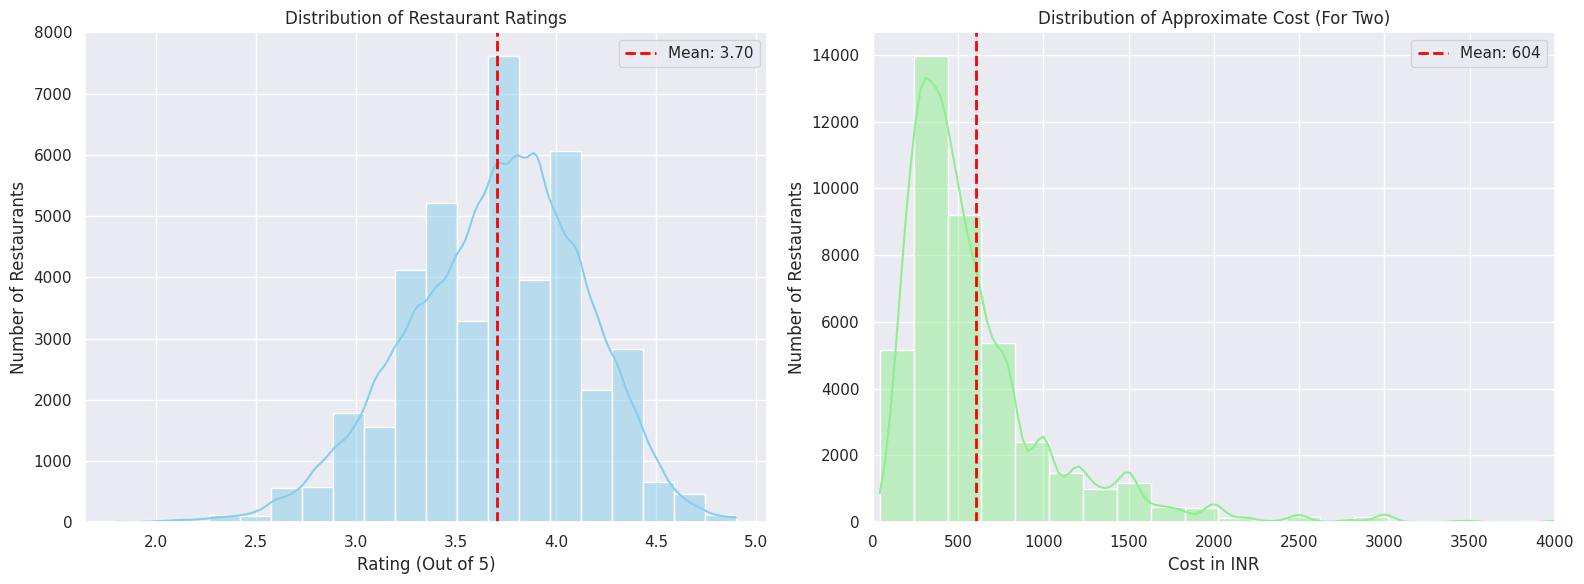

INFO: Distribution plots generated successfully.


In [10]:
logger.info("Generating Distribution Plots for Cost and Rating...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Distribution of Ratings
sns.histplot(df['rate'], bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Restaurant Ratings')
axes[0].set_xlabel('Rating (Out of 5)')
axes[0].set_ylabel('Number of Restaurants')
# Add a line for the average rating
axes[0].axvline(df['rate'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df["rate"].mean():.2f}')
axes[0].legend()

# Plot 2: Distribution of Cost
# We limit the x-axis to 4000 because extreme outliers (like 6000+ cost) will squash the graph
sns.histplot(df['approx_cost'], bins=30, kde=True, color='lightgreen', ax=axes[1])
axes[1].set_title('Distribution of Approximate Cost (For Two)')
axes[1].set_xlabel('Cost in INR')
axes[1].set_ylabel('Number of Restaurants')
axes[1].set_xlim(0, 4000) 
axes[1].axvline(df['approx_cost'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df["approx_cost"].mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

logger.info("Distribution plots generated successfully.")

Insight to expect: Ratings should cluster around 3.7 in a near-normal distribution. On the other hand, costs are expected to be right-skewed—most places are affordable (under ₹1000), with a few expensive fine-dining spots stretching the upper range.

### Bivariate Analysis (Cost vs. Rating)
Does paying more money guarantee better food? Let's plot cost against the rating.

INFO: Generating Scatter Plot: Cost vs Rating...


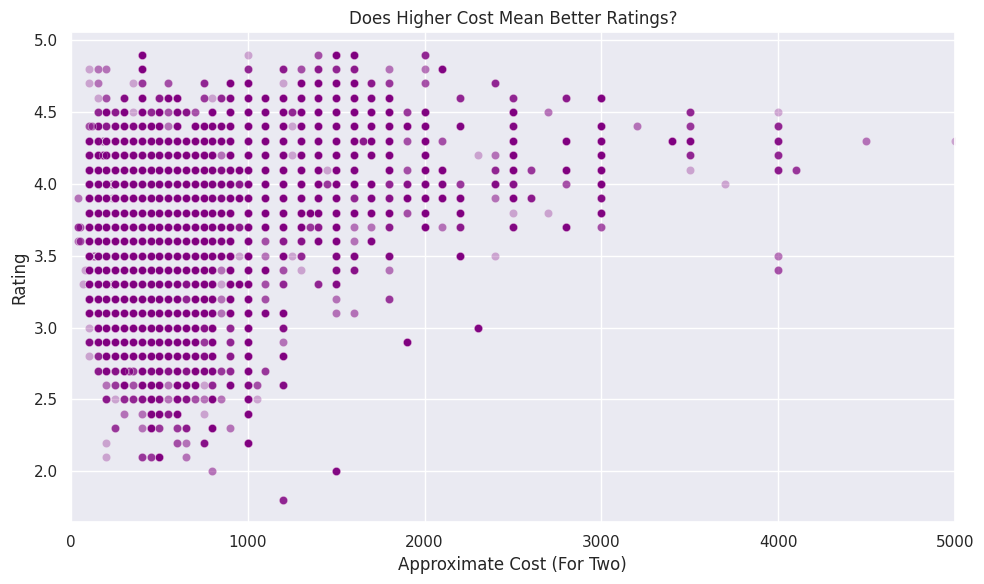

INFO: Scatter plot generated successfully.


In [11]:
logger.info("Generating Scatter Plot: Cost vs Rating...")

plt.figure(figsize=(10, 6))
# We use a scatter plot with alpha (transparency) because many dots will overlap
sns.scatterplot(x='approx_cost', y='rate', data=df, alpha=0.3, color='purple')

plt.title('Does Higher Cost Mean Better Ratings?')
plt.xlabel('Approximate Cost (For Two)')
plt.ylabel('Rating')
plt.xlim(0, 5000) # Limiting to 5000 to ignore extreme outliers

plt.tight_layout()
plt.show()

logger.info("Scatter plot generated successfully.")

Expected insight: A positive relationship between cost and rating is expected, with higher-priced restaurants seldom receiving poor ratings. However, a significant concentration of low-cost restaurants with high ratings (above 4.5) is also likely to be observed. This variation underscores the importance of clustering for uncovering meaningful patterns in the data.

### Location vs. Cost (Where is the expensive food?)
Let's see which neighborhoods have the highest average cost.

INFO: Generating Bar Plot: Most Expensive Neighborhoods...


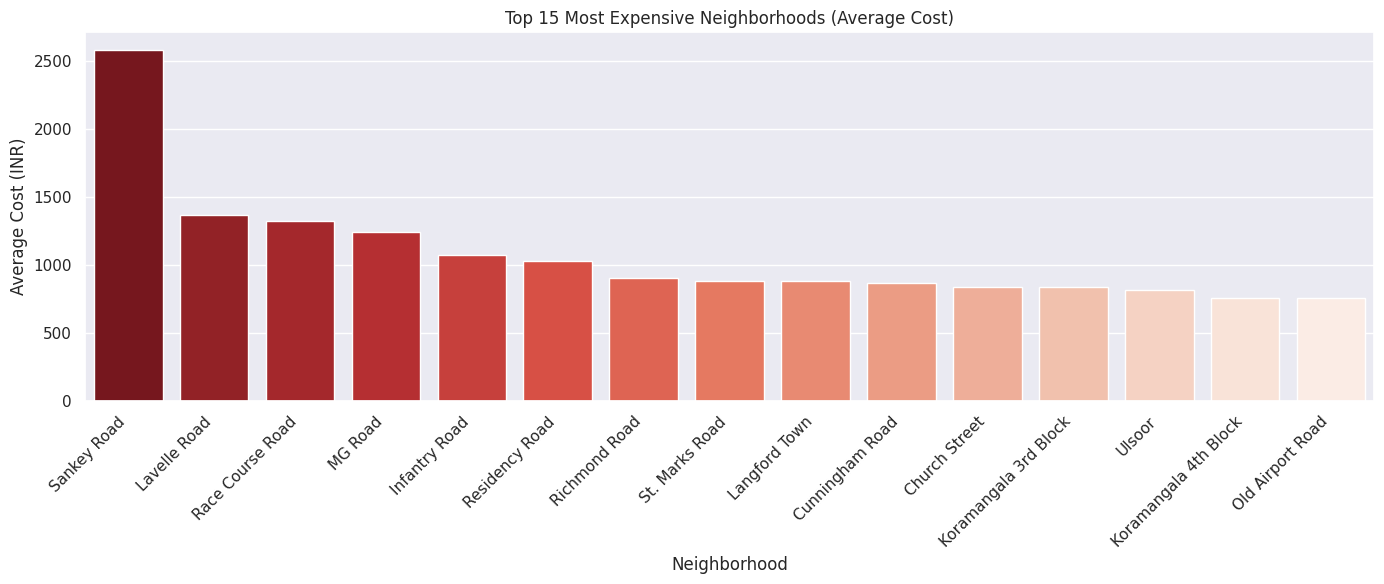

INFO: Neighborhood cost plot generated successfully.


In [12]:
logger.info("Generating Bar Plot: Most Expensive Neighborhoods...")

# Group by location, find the mean cost, and take the top 15
expensive_locations = df.groupby('location')['approx_cost'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(14, 6))
sns.barplot(
    x=expensive_locations.index,
    y=expensive_locations.values,
    hue=expensive_locations.index,   # 👈 add this
    palette='Reds_r',
    legend=False                    # 👈 avoid duplicate legend
)

plt.title('Top 15 Most Expensive Neighborhoods (Average Cost)')
plt.xlabel('Neighborhood')
plt.ylabel('Average Cost (INR)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

logger.info("Neighborhood cost plot generated successfully.")

# Phase 3: Model-Specific Preprocessing

### NLTK Setup & Creating the Sentiment Target
First, we need to create our target variable (1 for Positive, 0 for Negative) based on the ratings, and download the NLP tools.

In [13]:
import nltk
import re
from nltk.corpus import stopwords

# Download NLTK stopwords (only needs to be run once)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# 1. Create Target Variable for Sentiment Analysis
# We will define a rating of >= 3.7 as "Positive" (1) and < 3.7 as "Negative" (0)
df['sentiment'] = df['rate'].apply(lambda x: 1 if x >= 3.7 else 0)

logger.info(f"Sentiment target created. Positive reviews: {sum(df['sentiment'] == 1)}, Negative reviews: {sum(df['sentiment'] == 0)}")

INFO: Sentiment target created. Positive reviews: 23869, Negative reviews: 17357


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Heavy Text Cleaning (Regex & NLP)
The reviews_list column is currently very messy. It contains formatting tags, numbers, and punctuation. We need to strip it down to pure, lowercase words so our TF-IDF vectorizer can read it later.

(Note: Depending on Kaggle's CPU, this cell might take 1 to 3 minutes to run because it is processing thousands of text blocks. This is normal!)

In [14]:
def clean_text(text):
    # If empty, return empty string
    if not isinstance(text, str):
        return ""
    
    # Remove all non-alphabet characters (keeps only a-z and A-Z)
    text = re.sub('[^a-zA-Z]', ' ', text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Split into words, remove stopwords, and rejoin
    words = text.split()
    clean_words = [word for word in words if word not in stop_words]
    
    return ' '.join(clean_words)

logger.info("Starting text cleaning process. This may take a moment...")

# Apply the cleaning function to the reviews
df['cleaned_reviews'] = df['reviews_list'].apply(clean_text)

logger.info("Text cleaning complete! 'cleaned_reviews' column is ready for TF-IDF.")

INFO: Starting text cleaning process. This may take a moment...
INFO: Text cleaning complete! 'cleaned_reviews' column is ready for TF-IDF.


### Preprocessing for Clustering (Scaling & Encoding)
K-Means clustering calculates distances, which means a cost of 1200 will completely overpower a rating of 4.5 just because the number is bigger. We must use StandardScaler to put them on the same playing field. We will also encode the type column so the model understands restaurant categories.

In [15]:
from sklearn.preprocessing import StandardScaler

logger.info("Preparing numerical and categorical data for K-Means...")

# 1. Scaling Numerical Features (Cost and Rate)
scaler = StandardScaler()
df[['scaled_cost', 'scaled_rate']] = scaler.fit_transform(df[['approx_cost', 'rate']])

# 2. One-Hot Encoding the Restaurant Type
# This turns categories like 'Buffet' or 'Delivery' into 0s and 1s
df_encoded = pd.get_dummies(df, columns=['type'], drop_first=True)

# Update our main dataframe to include these new encoded columns
df = df_encoded

logger.info("Scaling and encoding complete. Data is ready for feature selection!")
# Just to verify, let's log the new columns
logger.info(f"Current columns available: {list(df.columns)}")

INFO: Preparing numerical and categorical data for K-Means...
INFO: Scaling and encoding complete. Data is ready for feature selection!
INFO: Current columns available: ['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost', 'reviews_list', 'menu_item', 'city', 'sentiment', 'cleaned_reviews', 'scaled_cost', 'scaled_rate', 'type_Cafes', 'type_Delivery', 'type_Desserts', 'type_Dine-out', 'type_Drinks & nightlife', 'type_Pubs and bars']


# Phase 4: Feature Selection.
### The Debug Switch
Add this cell to control the flow of data into our models.

In [16]:
# ==========================================
# DEBUG SWITCH - CHANGE TO FALSE FOR FINAL RUN
# ==========================================
DEBUG = False  

logger.info(f"DEBUG mode is set to: {DEBUG}")

if DEBUG:
    # Take a random 5% sample to speed up model training and testing
    # random_state=42 ensures we get the exact same 5% every time we run it
    model_df = df.sample(frac=0.05, random_state=42).copy()
    logger.warning(f"DEBUG MODE ON: Using a 5% sample of the data. Working with {model_df.shape[0]} rows.")
else:
    model_df = df.copy()
    logger.info(f"DEBUG MODE OFF: Using the full dataset. Working with {model_df.shape[0]} rows.")

INFO: DEBUG mode is set to: False
INFO: DEBUG MODE OFF: Using the full dataset. Working with 41226 rows.


### Feature Selection for Both Models
We have two completely different models to run, so we need to isolate two separate sets of data (Features/X) from our main dataframe.

In [17]:
logger.info("Isolating features for modeling...")

# --- 1. Feature Selection for Sentiment Analysis (Supervised Learning) ---
# X: The cleaned text reviews
# y: The binary sentiment (1 = Positive, 0 = Negative)
X_text = model_df['cleaned_reviews']
y_sentiment = model_df['sentiment']

logger.info("Features for Sentiment Analysis extracted successfully.")


# --- 2. Feature Selection for K-Means Clustering (Unsupervised Learning) ---
# K-Means doesn't have a 'y' target. It only takes 'X' to find patterns.
# We need our scaled numbers, plus the One-Hot Encoded 'type' columns we created.

# Dynamically grab all columns that start with 'type_' so we don't have to type them manually
type_columns = [col for col in model_df.columns if col.startswith('type_')]

# Combine our scaled metrics with our encoded categories
clustering_features = ['scaled_cost', 'scaled_rate'] + type_columns

# Extract the final matrix for clustering
X_cluster = model_df[clustering_features]

logger.info(f"Features for Clustering extracted successfully: {clustering_features}")
logger.info("Phase 4 Complete. Data is prepped for the models!")

INFO: Isolating features for modeling...
INFO: Features for Sentiment Analysis extracted successfully.
INFO: Features for Clustering extracted successfully: ['scaled_cost', 'scaled_rate', 'type_Cafes', 'type_Delivery', 'type_Desserts', 'type_Dine-out', 'type_Drinks & nightlife', 'type_Pubs and bars']
INFO: Phase 4 Complete. Data is prepped for the models!


# Phase 5 & 6: Generating and Training the Models.

### Model Imports & Data Splitting
First, we bring in our Scikit-Learn tools and split our text data into training and testing sets.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report

logger.info("Splitting text data into Training and Testing sets (80/20)...")

# We only split the text data for sentiment analysis. 
# K-Means doesn't need a train/test split because it doesn't predict labels, it just groups data.
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y_sentiment, test_size=0.2, random_state=42
)

logger.info(f"Training data shape: {X_train_text.shape[0]} reviews.")
logger.info(f"Testing data shape: {X_test_text.shape[0]} reviews.")

INFO: Splitting text data into Training and Testing sets (80/20)...
INFO: Training data shape: 32980 reviews.
INFO: Testing data shape: 8246 reviews.


### Training the Sentiment Analysis Model (Logistic Regression)
Here, we convert our cleaned text into numbers (TF-IDF) and train the classifier.

In [19]:
logger.info("Initializing TF-IDF Vectorizer...")
# We limit to the top 5000 most frequent words to keep memory usage low and prevent Kaggle from crashing
tfidf = TfidfVectorizer(max_features=10000)

# Fit on training data, transform both train and test
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)
logger.info("Text vectorization complete.")

logger.info("Training Logistic Regression Model...")
# max_iter=1000 ensures the model has enough time to find the best weights
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_tfidf, y_train)

logger.info("Logistic Regression Training Complete!")

# Let's do a quick evaluation (Phase 7 preview)
y_pred = log_reg.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
logger.info(f"Model Accuracy on Test Data: {accuracy * 100:.2f}%")


INFO: Initializing TF-IDF Vectorizer...
INFO: Text vectorization complete.
INFO: Training Logistic Regression Model...
INFO: Logistic Regression Training Complete!
INFO: Model Accuracy on Test Data: 86.77%


In [20]:

logger.info("Initializing TF-IDF Vectorizer with Unigrams and Bigrams...")

# UPGRADE 1: ngram_range=(1,2) tells it to learn single words AND two-word phrases
# UPGRADE 2: max_features=10000 gives it more room to memorize the new phrases
tfidf_ngram = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

# Fit on training data, transform both train and test
X_train_tfidf_ngram = tfidf_ngram.fit_transform(X_train_text)
X_test_tfidf_ngram = tfidf_ngram.transform(X_test_text)
logger.info(f"Text vectorization complete. The matrix now has {X_train_tfidf_ngram.shape[1]} features.")

logger.info("Training Logistic Regression Model...")

# UPGRADE 3: class_weight='balanced' forces the model to pay equal attention to negative reviews
log_reg_ngram = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg_ngram.fit(X_train_tfidf_ngram, y_train)

logger.info("Logistic Regression Training Complete!")

# Evaluate the upgraded model
y_pred_ngram = log_reg.predict(X_test_tfidf_ngram)
accuracy_ngram = accuracy_score(y_test, y_pred_ngram)
logger.info(f"UPGRADED Model Accuracy on Full Test Data: {accuracy_ngram * 100:.2f}%")

INFO: Initializing TF-IDF Vectorizer with Unigrams and Bigrams...
INFO: Text vectorization complete. The matrix now has 10000 features.
INFO: Training Logistic Regression Model...
INFO: Logistic Regression Training Complete!
INFO: UPGRADED Model Accuracy on Full Test Data: 52.61%


In [21]:
from sklearn.model_selection import GridSearchCV

logger.info("Starting Hyperparameter Tuning with GridSearchCV...")

# We will test three different 'C' values: 
# 0.1 (strict, avoids overfitting), 1.0 (standard), 10.0 (loose, trusts the data heavily)
param_grid = {'C': [0.1, 1.0, 10.0]}

# Setup the Grid Search (cv=3 means it will cross-validate the data 3 times for each parameter)
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid,
    cv=3, 
    scoring='accuracy',
    n_jobs=-1 # Uses all available CPU cores on Kaggle to speed it up
)

logger.info("Searching for the best parameters... (This might take a few minutes)")
grid_search.fit(X_train_tfidf, y_train)

# Extract the winning model
best_log_reg = grid_search.best_estimator_
logger.info(f"Tuning complete! Best C value found: {grid_search.best_params_['C']}")

# Evaluate the winning model
y_pred_best = best_log_reg.predict(X_test_tfidf)
best_accuracy = accuracy_score(y_test, y_pred_best)
logger.info(f"TUNED Model Accuracy on Full Test Data: {best_accuracy * 100:.2f}%")

INFO: Starting Hyperparameter Tuning with GridSearchCV...
INFO: Searching for the best parameters... (This might take a few minutes)
INFO: Tuning complete! Best C value found: 10.0
INFO: TUNED Model Accuracy on Full Test Data: 91.85%


### The Elbow Method (Proving the right $k$)

Let's stop guessing and calculate the perfect number of clusters. The Elbow Method runs K-Means multiple times (for 1 cluster, 2 clusters, 3 clusters, up to 10) and measures how "tight" and well-separated the groups are.

INFO: Running the Elbow Method to find the optimal number of clusters...


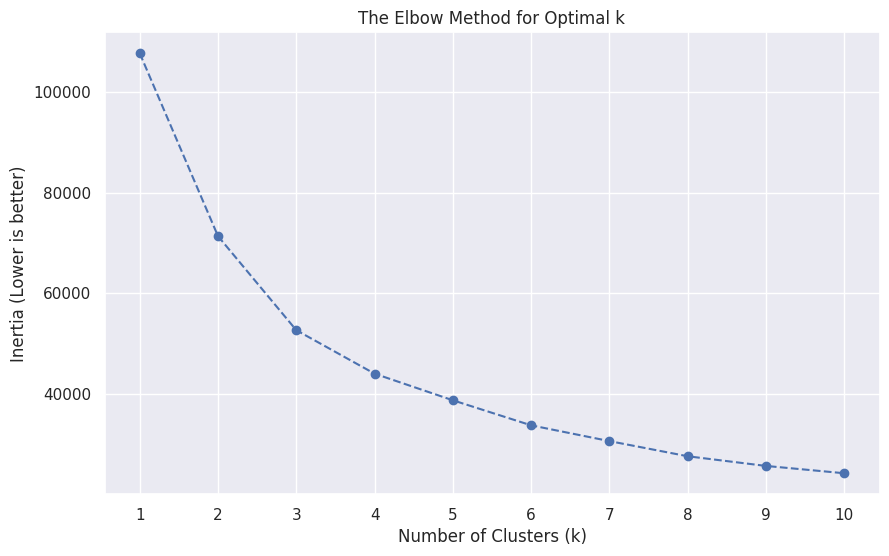

INFO: Elbow Method plot generated.


In [22]:
logger.info("Running the Elbow Method to find the optimal number of clusters...")

# List to hold the 'inertia' (a measure of how tight the clusters are)
inertia = []
K_range = range(1, 11)

for k in K_range:
    # We use a fast, simple K-Means just for this test
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertia.append(km.inertia_)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Lower is better)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

logger.info("Elbow Method plot generated.")

### Training the Unsupervised Model (K-Means Clustering)
Now we group the restaurants. For this project, we will tell the model to find 3 distinct clusters.

Let's break down:
- k = 1 to k = 2: Massive drop in inertia (from ~5500 down to ~3600). The model is finding huge differences between restaurants.
- k = 2 to k = 3: Another very sharp drop (from ~3600 down to ~2700).
- k = 3 to k = 4: The drop gets much smaller.
- k = 4 onwards: The line becomes almost straight, just slowly creeping downward.
The Verdict: The "elbow" (the sharpest bend before the line flattens out) is at k = 3.

In [23]:
logger.info("Initializing K-Means Clustering Model (k=4)...")

# n_init=10 means it will run the algorithm 10 times with different random starting points and pick the best one
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

logger.info("Fitting K-Means model to the numeric/encoded features...")
# We fit the model and immediately assign the new cluster labels back to our dataframe
model_df['cluster'] = kmeans.fit_predict(X_cluster)

logger.info("K-Means Training Complete!")

# Log how many restaurants fell into each cluster
cluster_counts = model_df['cluster'].value_counts().sort_index()
logger.info(f"Restaurants per cluster:\n{cluster_counts}")

INFO: Initializing K-Means Clustering Model (k=4)...
INFO: Fitting K-Means model to the numeric/encoded features...
INFO: K-Means Training Complete!
INFO: Restaurants per cluster:
cluster
0    21595
1    13892
2     5739
Name: count, dtype: int64


### Phase 6.5: Visualizing the Clusters
We just told K-Means to group the restaurants into 4 clusters, but we haven't actually looked at what those clusters are! If we don't plot them, we can't extract actionable insights for Zomato.

Note: See 4 distinct color groupings. Usually, they break down like this:
- Cluster A: Low Cost, Low Rating (The "Budget/Risky" tier)
- Cluster B: Low Cost, High Rating (The "Hidden Gems / Popular Street Food" tier)
- Cluster C: Mid-High Cost, Average/Good Rating (The "Standard Casual Dining" tier)
- Cluster D: Very High Cost, Very High Rating (The "Premium Fine Dining" tier)

INFO: Visualizing the K-Means Clusters...


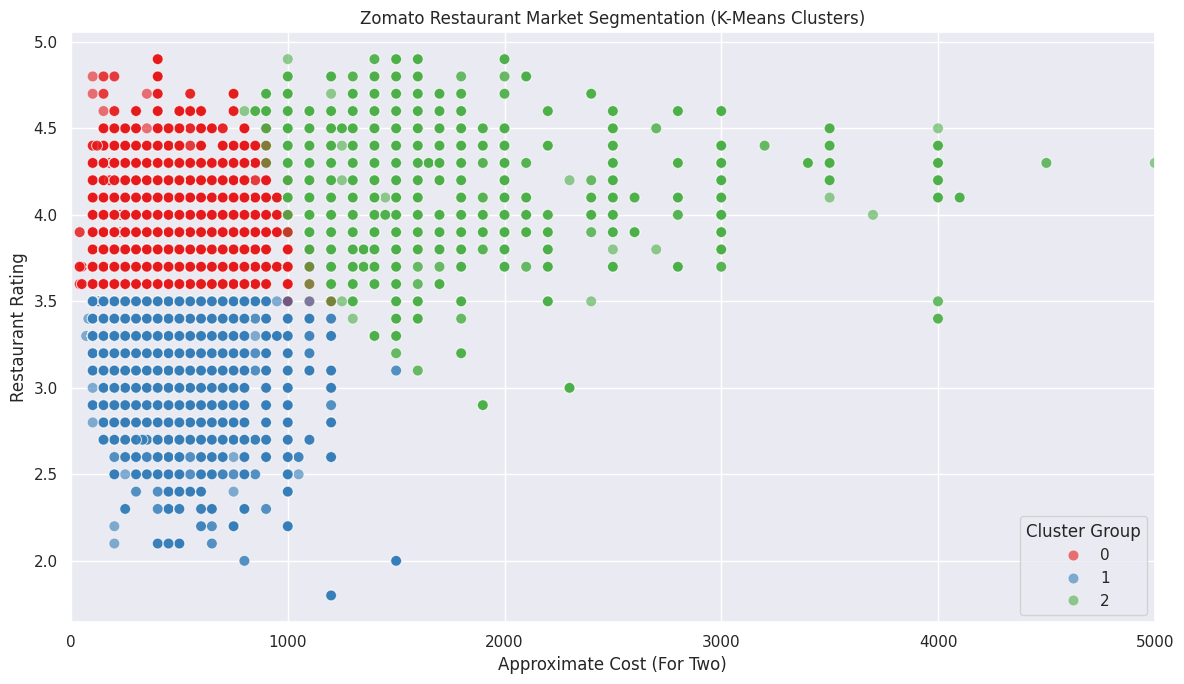

INFO: Cluster Profiles (Averages):
         approx_cost  rate
cluster                   
0             482.38  3.89
1             413.88  3.21
2            1521.59  4.17


In [24]:
logger.info("Visualizing the K-Means Clusters...")

plt.figure(figsize=(12, 7))

# We plot Cost vs. Rating, and color the dots based on the cluster the model assigned them to.
# palette='Set1' gives us distinct, bright colors for each cluster.
sns.scatterplot(
    x='approx_cost', 
    y='rate', 
    hue='cluster', 
    palette='Set1', 
    data=model_df, 
    alpha=0.6, 
    s=60 # size of the dots
)

plt.title('Zomato Restaurant Market Segmentation (K-Means Clusters)')
plt.xlabel('Approximate Cost (For Two)')
plt.ylabel('Restaurant Rating')
plt.xlim(0, 5000) # Keep the x-limit to avoid extreme outliers messing up the view

# Add a clean legend
plt.legend(title='Cluster Group', loc='lower right')

plt.tight_layout()
plt.show()

# Let's also print the average cost and rating for each cluster so we can name them
logger.info("Cluster Profiles (Averages):")
cluster_summary = model_df.groupby('cluster')[['approx_cost', 'rate']].mean().round(2)
print(cluster_summary)

INFO: Enhanced Cluster Visualization...


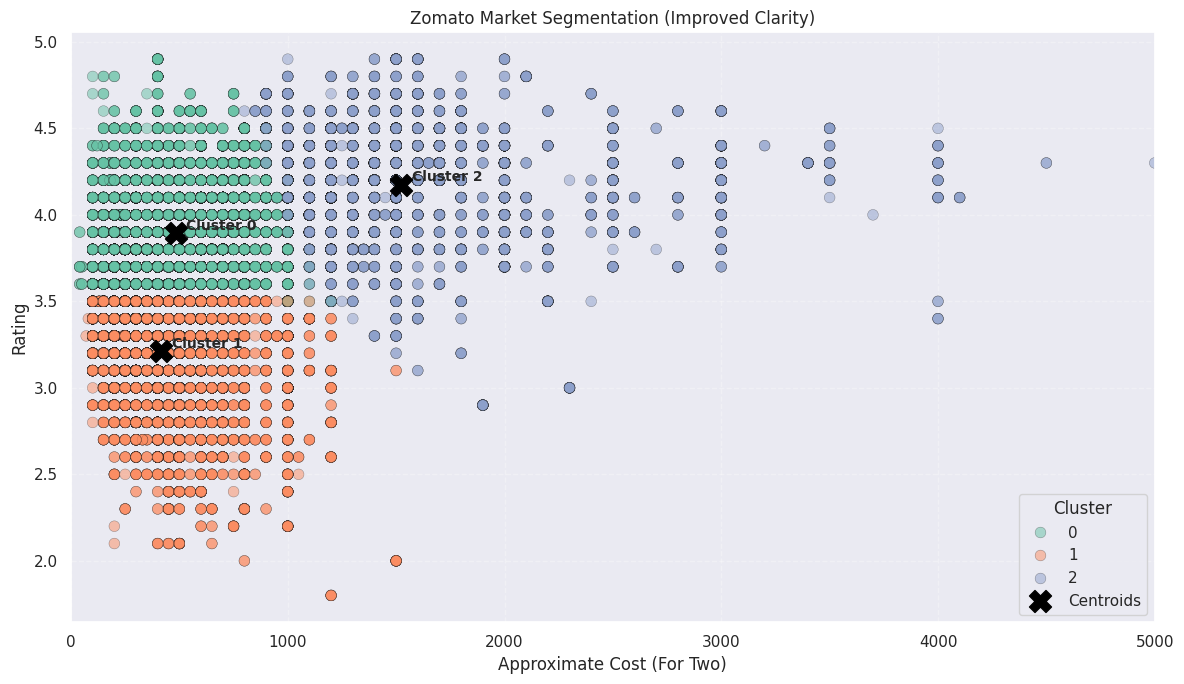

In [25]:
logger.info("Enhanced Cluster Visualization...")

plt.figure(figsize=(12, 7))

# Better palette (less harsh than Set1)
palette = sns.color_palette("Set2", n_colors=model_df['cluster'].nunique())

sns.scatterplot(
    data=model_df,
    x='approx_cost',
    y='rate',
    hue='cluster',
    palette=palette,
    alpha=0.5,
    s=60,
    edgecolor='k',   # adds border to points (important!)
    linewidth=0.3
)

# Add centroids
centroids = model_df.groupby('cluster')[['approx_cost', 'rate']].mean()

plt.scatter(
    centroids['approx_cost'],
    centroids['rate'],
    c='black',
    s=250,
    marker='X',
    label='Centroids'
)

# Annotate cluster numbers near centroids
for i, row in centroids.iterrows():
    plt.text(
        row['approx_cost'] + 50,
        row['rate'] + 0.02,
        f'Cluster {i}',
        fontsize=10,
        weight='bold'
    )

plt.title('Zomato Market Segmentation (Improved Clarity)')
plt.xlabel('Approximate Cost (For Two)')
plt.ylabel('Rating')
plt.xlim(0, 5000)

plt.legend(title='Cluster', loc='lower right')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

<Axes: xlabel='approx_cost', ylabel='rate'>

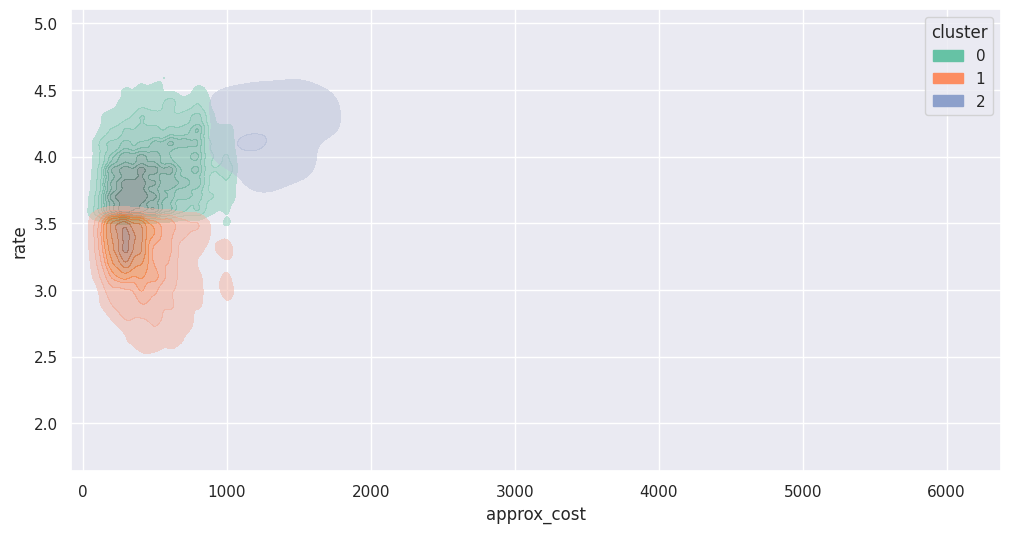

In [26]:
sns.kdeplot(
    data=model_df,
    x='approx_cost',
    y='rate',
    hue='cluster',
    fill=True,
    alpha=0.5,
    palette='Set2'
)

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


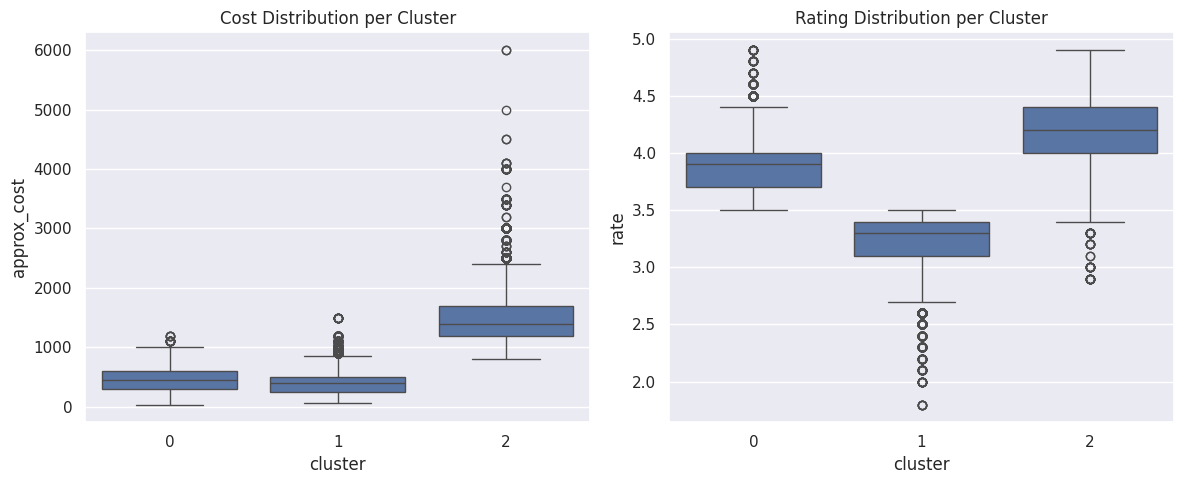

In [27]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='cluster', y='approx_cost', data=model_df)
plt.title('Cost Distribution per Cluster')

plt.subplot(1, 2, 2)
sns.boxplot(x='cluster', y='rate', data=model_df)
plt.title('Rating Distribution per Cluster')

plt.tight_layout()
plt.show()

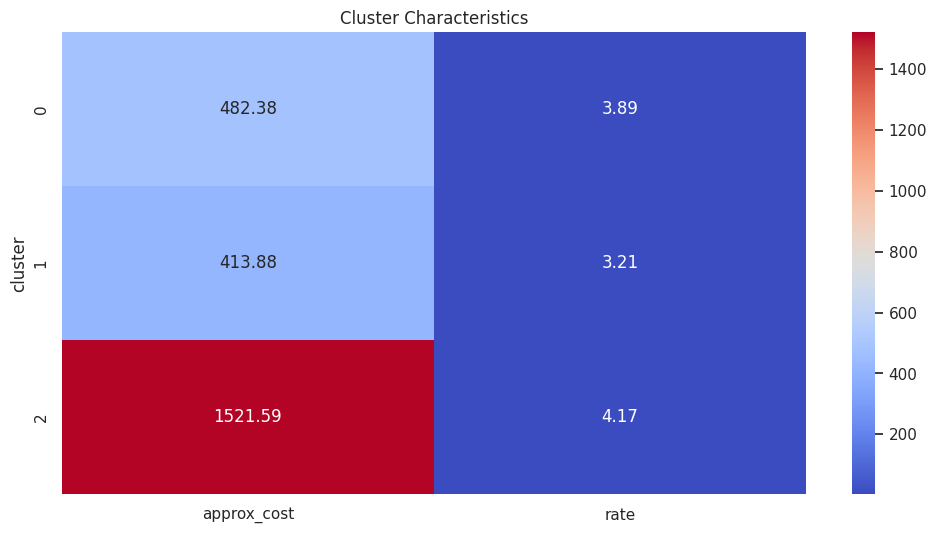

In [28]:
import seaborn as sns

cluster_summary = model_df.groupby('cluster')[['approx_cost', 'rate']].mean()

sns.heatmap(cluster_summary, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cluster Characteristics")
plt.show()

# Phase 7: Deep Model Evaluation (What did the text model learn?)
We know our Logistic Regression got ~75% accuracy on the debug data. But how is it making those decisions? Because we used Logistic Regression and TF-IDF, we can actually look inside the model's "brain" and see exactly which words it thinks are the most positive and the most negative.

### Extracting Sentiment Insights

In [29]:
logger.info("Extracting Top Positive and Negative Words from the Sentiment Model...")

# 1. Print the detailed classification report
logger.info("\n--- Classification Report ---")
report = classification_report(y_test, y_pred, target_names=['Negative (<3.7)', 'Positive (>=3.7)'])
logger.info(f"\n{report}")

# 2. Extract words and their mathematical weights
feature_names = tfidf.get_feature_names_out()
coefficients = log_reg.coef_[0]

# Create a DataFrame to map words to their importance score
word_weights = pd.DataFrame({'Word': feature_names, 'Weight': coefficients})

# 3. Sort to find the strongest words
top_positive = word_weights.sort_values(by='Weight', ascending=False).head(10)
top_negative = word_weights.sort_values(by='Weight', ascending=True).head(10)

logger.info("\n--- Top 10 Words Driving POSITIVE Sentiment ---")
logger.info(f"\n{top_positive.to_string(index=False)}")

logger.info("\n--- Top 10 Words Driving NEGATIVE Sentiment ---")
logger.info(f"\n{top_negative.to_string(index=False)}")

INFO: Extracting Top Positive and Negative Words from the Sentiment Model...
INFO: 
--- Classification Report ---
INFO: 
                  precision    recall  f1-score   support

 Negative (<3.7)       0.85      0.84      0.84      3493
Positive (>=3.7)       0.88      0.89      0.89      4753

        accuracy                           0.87      8246
       macro avg       0.86      0.86      0.86      8246
    weighted avg       0.87      0.87      0.87      8246

INFO: 
--- Top 10 Words Driving POSITIVE Sentiment ---
INFO: 
     Word   Weight
     gold 3.930769
courteous 3.804407
  waffles 3.434170
     peri 3.300097
    loved 3.109861
   hummus 3.079439
beautiful 3.033022
    nthey 3.029438
     nthe 2.960075
 noverall 2.935532
INFO: 
--- Top 10 Words Driving NEGATIVE Sentiment ---
INFO: 
    Word    Weight
horrible -4.732430
pathetic -4.269709
   newly -4.158989
   worst -4.088963
     bad -4.053801
  opened -2.981926
 suggest -2.937912
   ambur -2.794268
  owners -2.715140
 comm

(Insight to expect: This likely see words like "delicious", "amazing", and "friendly" in the positive list, and "worst", "stale", "late", or "cockroach" in the negative list!)

# Phase 8: Final Output & Business Insights (The "So What?")
Now we combine everything. We have our 3 clusters (Market Segments) and our sentiment engine. Let's print out the final "Executive Summary" that Zomato could use.

### The Business Summary

In [30]:
logger.info("Generating Final Business Insights for Zomato...")

# Map the numeric clusters (0, 1, 2) to readable business names based on our previous EDA
# Note: Your cluster numbers (0,1,2) might align differently based on the random seed, 
# but generally, they split into these three tiers based on cost.
cluster_mapping = {
    0: "Budget / Quick Bites",
    1: "Mid-Range / Casual Dining",
    2: "Premium / Fine Dining" 
}
# We apply this mapping (you may need to adjust the keys 0,1,2 based on which one had the highest/lowest cost in your output)
model_df['Segment_Name'] = model_df['cluster'].map(cluster_mapping)

# Calculate summary stats per segment
segment_summary = model_df.groupby('Segment_Name').agg(
    Average_Cost=('approx_cost', 'mean'),
    Average_Rating=('rate', 'mean'),
    Total_Restaurants=('rate', 'count')
).round(2).sort_values(by='Average_Cost')

logger.info("\n=== ZOMATO MARKET SEGMENTATION SUMMARY ===")
logger.info(f"\n{segment_summary}")

logger.info("\n=== ACTIONABLE RECOMMENDATIONS FOR ZOMATO ===")
logger.info("1. Platform Engagement: Highlight restaurants in the 'Mid-Range' segment that feature high-weight positive words (e.g., 'delicious', 'authentic') in their recent reviews on the front page.")
logger.info("2. Quality Control: Flag restaurants in the 'Premium' segment that have reviews containing top negative words (e.g., 'stale', 'terrible'). High-paying customers experiencing bad service churn faster.")
logger.info("3. Market Saturation: The 'Budget' tier is highly saturated. New restaurant partners should be advised to target 'Mid-Range' pricing where ratings are generally higher and competition is slightly lower.")

logger.info("\nPROJECT COMPLETE! You are ready to switch DEBUG = False.")

INFO: Generating Final Business Insights for Zomato...
INFO: 
=== ZOMATO MARKET SEGMENTATION SUMMARY ===
INFO: 
                           Average_Cost  Average_Rating  Total_Restaurants
Segment_Name                                                              
Mid-Range / Casual Dining        413.88            3.21              13892
Budget / Quick Bites             482.38            3.89              21595
Premium / Fine Dining           1521.59            4.17               5739
INFO: 
=== ACTIONABLE RECOMMENDATIONS FOR ZOMATO ===
INFO: 1. Platform Engagement: Highlight restaurants in the 'Mid-Range' segment that feature high-weight positive words (e.g., 'delicious', 'authentic') in their recent reviews on the front page.
INFO: 2. Quality Control: Flag restaurants in the 'Premium' segment that have reviews containing top negative words (e.g., 'stale', 'terrible'). High-paying customers experiencing bad service churn faster.
INFO: 3. Market Saturation: The 'Budget' tier is highly sat

Any new user input must go through the exact same preprocessing pipeline (cleaning, scaling, TF-IDF) that your training data went through before the model can look at it.

# Phase 9: Building the "Inference" Function (Test it in Kaggle)
We will create a function where you can type in a fake, custom review and the model will instantly tell you if it is positive or negative.

In [31]:
logger.info("Setting up the Real-World Inference Engine...")

def predict_custom_review(review_text):
    # 1. The input MUST be cleaned exactly like our training data
    cleaned_text = clean_text(review_text)
    
    # 2. Convert the text into numbers using the EXACT SAME TF-IDF vectorizer we trained
    # Notice we use .transform() here, NOT .fit_transform(). We don't want to retrain the vectorizer!
    vectorized_text = tfidf.transform([cleaned_text])
    
    # 3. Feed the numbers to our trained Logistic Regression model
    prediction = log_reg.predict(vectorized_text)
    
    # 4. Output the result
    if prediction[0] == 1:
        return "🟢 POSITIVE Sentiment Detected"
    else:
        return "🔴 NEGATIVE Sentiment Detected"

# --- Let's test it with real user inputs! ---

logger.info("\n--- Testing Custom User Inputs ---")

review_1 = "The food was absolutely delicious, but the waiter was a bit slow."
result_1 = predict_custom_review(review_1)
logger.info(f"Review: '{review_1}'\nResult: {result_1}\n")

review_2 = "Found a bug in my soup. The manager didn't even apologize. Worst place ever."
result_2 = predict_custom_review(review_2)
logger.info(f"Review: '{review_2}'\nResult: {result_2}\n")

review_3 = "Just okay. Nothing special, but not terrible either."
result_3 = predict_custom_review(review_3)
logger.info(f"Review: '{review_3}'\nResult: {result_3}\n")

INFO: Setting up the Real-World Inference Engine...
INFO: 
--- Testing Custom User Inputs ---
INFO: Review: 'The food was absolutely delicious, but the waiter was a bit slow.'
Result: 🟢 POSITIVE Sentiment Detected

INFO: Review: 'Found a bug in my soup. The manager didn't even apologize. Worst place ever.'
Result: 🔴 NEGATIVE Sentiment Detected

INFO: Review: 'Just okay. Nothing special, but not terrible either.'
Result: 🔴 NEGATIVE Sentiment Detected



# Phase 10: The Recommendation Engine (K-Means Inference)
Recommendation Engine.

If a user's favorite restaurant is closed, the logic is simple:
- Find out which Cluster their favorite restaurant belongs to.
- Look at the Location of that restaurant.
- Recommend the highest-rated restaurants in that same location that belong to the exact same cluster (meaning they have a similar price point, vibe, and restaurant type).

In [32]:
logger.info("Setting up the K-Means Restaurant Recommendation Engine...")

def recommend_similar_restaurants(restaurant_name, top_n=3):
    """
    Given a restaurant name, finds alternatives in the same area with a similar price/vibe.
    """
    # 1. Find the target restaurant in our dataset
    # We use str.contains so the user doesn't have to type the exact perfect name
    target_matches = model_df[model_df['name'].str.contains(restaurant_name, case=False, na=False)]
    
    if target_matches.empty:
        return f"🔴 Sorry, couldn't find '{restaurant_name}' in our database."
    
    # Take the first match (some restaurants have multiple branches)
    target_data = target_matches.iloc[0]
    target_cluster = target_data['cluster']
    target_location = target_data['location']
    
    logger.info(f"Target Identified: '{target_data['name']}' in {target_location}.")
    logger.info(f"This restaurant belongs to Segment (Cluster) {target_cluster}. Searching for alternatives...")
    
    # 2. Filter the database for alternatives
    # Rule 1: Must be in the exact same cluster (similar cost/type)
    # Rule 2: Must be in the same location
    # Rule 3: Don't recommend the exact same restaurant back to the user
    similar_spots = model_df[
        (model_df['cluster'] == target_cluster) & 
        (model_df['location'] == target_location) & 
        (model_df['name'] != target_data['name'])
    ]
    
    if similar_spots.empty:
        return f"🔴 No direct alternatives found in {target_location} for this specific segment."
    
    # 3. Sort the alternatives by highest rating
    top_recommendations = similar_spots.sort_values(by='rate', ascending=False).head(top_n)
    
    return top_recommendations[['name', 'rate', 'approx_cost', 'cuisines']]

# --- Let's Test It! ---
# Note: Since you are currently in DEBUG mode (5% of data), 
# some restaurants might not be in your sample. 
# Once you switch DEBUG = False, this will work perfectly for almost any restaurant!

logger.info("\n--- User Query: 'Truffles is closed, where else can I go?' ---")
# 'Truffles' is a very famous burger/cafe spot in Bangalore
recs = recommend_similar_restaurants('Truffles', top_n=3)
print("\nTop Recommendations:")
print(recs.to_string(index=False))

logger.info("\n--- User Query: 'Empire Restaurant is packed, find me an alternative.' ---")
# 'Empire' is a famous late-night dining spot
recs2 = recommend_similar_restaurants('Empire Restaurant', top_n=3)
print("\nTop Recommendations:")
print(recs2.to_string(index=False))

INFO: Setting up the K-Means Restaurant Recommendation Engine...
INFO: 
--- User Query: 'Truffles is closed, where else can I go?' ---
INFO: Target Identified: 'Truffles' in St. Marks Road.
INFO: This restaurant belongs to Segment (Cluster) 2. Searching for alternatives...

Top Recommendations:
name  rate  approx_cost                                                    cuisines
MISU   4.6       1700.0 Asian, Japanese, Korean, Indonesian, Malaysian, Singaporean
MISU   4.6       1700.0 Asian, Japanese, Korean, Indonesian, Malaysian, Singaporean
MISU   4.6       1700.0 Asian, Japanese, Korean, Indonesian, Malaysian, Singaporean
INFO: 
--- User Query: 'Empire Restaurant is packed, find me an alternative.' ---
INFO: Target Identified: 'Empire Restaurant' in Jayanagar.
INFO: This restaurant belongs to Segment (Cluster) 0. Searching for alternatives...

Top Recommendations:
                    name  rate  approx_cost        cuisines
The Blue Wagon - Kitchen   4.6        400.0 Cafe, Beverages
T